# Deep Learning Assignment 2
#### By: Logan Justin Gunawan (S4096363)

## The Task:

I have built the company Litmus pty with my friend. Litmus pty runs studies on the deconstruction and analysis of memes and how they use certain psychological techniques to elicit a response from a viewer. Previously, we have done all of this analysis by hand, however, we would like to expand our reach by creating a model which automatically detects, what psychological techniques a meme uses, as well as what part of the meme specifically uses each technique. We have 22 possible techniques (listed under 'techniques_list_task3.txt') to choose from, + 1 for a meme which does not use any listed technique shown. Because a meme can use multiple techniques, or none at all, this is a multi-label classification task.

## Loading Libraries

In [102]:
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
import re, os, math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## The Data

In [104]:
LABELS = [  "Appeal to authority",
            "Appeal to fear/prejudice",
            "Black-and-white Fallacy/Dictatorship",
            "Causal Oversimplification",
            "Doubt",
            "Exaggeration/Minimisation",
            "Flag-waving",
            "Glittering generalities (Virtue)",
            "Loaded Language",
            "Misrepresentation of Someone's Position (Straw Man)",
            "Name calling/Labeling",
            "Obfuscation, Intentional vagueness, Confusion",
            "Presenting Irrelevant Data (Red Herring)",
            "Reductio ad hitlerum",
            "Repetition",
            "Slogans",
            "Smears",
            "Thought-terminating cliché",
            "Whataboutism",
            "Bandwagon",
            "Transfer",
            "Appeal to (Strong) Emotions"
]

dev_set_task1 = pd.read_json("data_2026_A2/data/dev_set_task1.txt")
dev_set_task2 = pd.read_json("data_2026_A2/data/dev_set_task2.txt")
test_set_task1 = pd.read_json("data_2026_A2/data/test_set_task1.txt")
test_set_task2 = pd.read_json("data_2026_A2/data/test_set_task2.txt")
train_set_task1 = pd.read_json("data_2026_A2/data/training_set_task1.txt")
train_set_task2 = pd.read_json("data_2026_A2/data/training_set_task2.txt")

all_set_task1 = pd.concat([dev_set_task1, train_set_task1, test_set_task1], 
                          axis = 0)

print(all_set_task1.dtypes)
print(len(all_set_task1))

print(f"Task 1 Train Dataset Length: {len(train_set_task1)}")
print(f"Task 2 Train Dataset Length: {len(train_set_task2)}")
print(f"Task 1 Test Dataset Length: {len(test_set_task1)}")
print(f"Task 2 Test Dataset Length: {len(test_set_task2)}")
print(f"Task 1 Dev Dataset Length: {len(dev_set_task1)}")
print(f"Task 2 Dev Dataset Length: {len(dev_set_task2)}")

all_set_task1.head()

id        object
labels    object
text      object
dtype: object
951
Task 1 Train Dataset Length: 688
Task 2 Train Dataset Length: 688
Task 1 Test Dataset Length: 200
Task 2 Test Dataset Length: 200
Task 1 Dev Dataset Length: 63
Task 2 Dev Dataset Length: 63


,id,labels,text
0,62_batch_2,[],"*President* Biden?\n\nPlease, no.\n"
1,111_batch_2,"[Loaded Language, Name calling/Labeling]","JOE VERSUS THE VOLCANIC KREMLIN DON\n\n""WILL ..."
2,167_batch_2,[],ANTI-VAXXERS BE LIKE... \n\nHANG ON A SEC - JU...
3,93_batch_2,[],VIRUS BINGO\nFREE 32 SPACE\n
4,153_batch_2,"[Exaggeration/Minimisation, Loaded Language, N...",Never thought l'd die fighting IRRESPONSIBLY R...


Text(0.5, 1.0, 'Label Distribution')

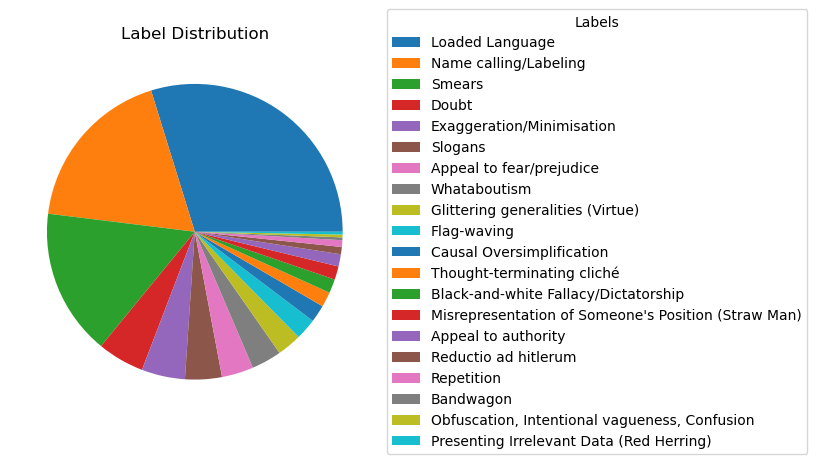

In [105]:
label_counts = Counter(
    label
    for labels in all_set_task1["labels"]
    for label in labels
)

label_counts_df = pd.DataFrame(label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(label_counts_df["Count"].values)

plt.legend(wedges,
           label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")

### Label Encoding

In [106]:
label_to_idx = {label : i for i, label in enumerate(LABELS)}

def encode_labels(labels):
    encoded = [0] * len(LABELS)
    for label in labels:
        encoded[label_to_idx[label]] = 1

    return torch.tensor(encoded, dtype=torch.float32)

train_set_task1["label_encoded"] = train_set_task1["labels"].apply(encode_labels)
test_set_task1["label_encoded"] = test_set_task1["labels"].apply(encode_labels)
dev_set_task1["label_encoded"] = dev_set_task1["labels"].apply(encode_labels)

train_set_task1.head()

,id,labels,text,label_encoded
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,"[tensor(0.), tensor(0.), tensor(1.), tensor(0...."
1,189,[],This is not an accident!,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,"[tensor(0.), tensor(0.), tensor(0.), tensor(1...."
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."


## Utilities

#### Generating Label Weights

In [107]:
# Generating Label Weights
task1_label_counts = Counter(label
                             for labels in train_set_task1["labels"]
                             for label in labels)

total = len(train_set_task1)
total_labels = len(LABELS)

task1_label_weights = torch.tensor(
    [total / (total_labels * task1_label_counts[label]) 
     if task1_label_counts[label] > 0 else 0
     for label in LABELS],
    dtype=torch.float32
).to(device)

print('Label weights for Task 1:')
for i, name in enumerate(LABELS):
    print(f'{name}: {task1_label_weights[i].item():.2f}')

"""
task1_label_counts_df = pd.DataFrame(task1_label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(task1_label_counts_df["Count"].values)

plt.legend(wedges,
           task1_label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")
"""

Label weights for Task 1:
Appeal to authority: 2.41
Appeal to fear/prejudice: 0.73
Black-and-white Fallacy/Dictatorship: 1.74
Causal Oversimplification: 1.16
Doubt: 0.65
Exaggeration/Minimisation: 0.60
Flag-waving: 1.16
Glittering generalities (Virtue): 0.98
Loaded Language: 0.09
Misrepresentation of Someone's Position (Straw Man): 1.56
Name calling/Labeling: 0.14
Obfuscation, Intentional vagueness, Confusion: 7.82
Presenting Irrelevant Data (Red Herring): 31.27
Reductio ad hitlerum: 3.47
Repetition: 3.91
Slogans: 0.71
Smears: 0.16
Thought-terminating cliché: 1.56
Whataboutism: 0.78
Bandwagon: 15.64
Transfer: 0.00
Appeal to (Strong) Emotions: 0.00


'\ntask1_label_counts_df = pd.DataFrame(task1_label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)\n\nwedges, _ = plt.pie(task1_label_counts_df["Count"].values)\n\nplt.legend(wedges,\n           task1_label_counts_df["Label"].values,\n           title="Labels",\n           bbox_to_anchor=(1, 0.5),\n           loc="center left")\n\nplt.title("Label Distribution")\n'

#### Training Utilities (Adapted from Labs)

In [108]:
def train_one_epoch(model, loader, optimizer, criterion, tokenizer_mode=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        if tokenizer_mode:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
            loss = outputs.loss
            logits = outputs.logits
        else:
            x, y, lengths = batch
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        probabilities = torch.sigmoid(logits)
        predicted = (probabilities >= 0.5).float()
        correct += (predicted == y).sum().item()
        total += y.numel()
    return total_loss / total, correct / total


def evaluate_model(model, loader, criterion, tokenizer_mode=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for batch in loader:
            if tokenizer_mode:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                y = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
                loss = outputs.loss
                logits = outputs.logits
            else:
                x, y, lengths = batch
                x, y = x.to(device), y.to(device)
                logits = model(x, lengths)
                loss = criterion(logits, y)
            
            total_loss += loss.item() * y.size(0)
            probabilities = torch.sigmoid(logits)
            predicted = (probabilities >= 0.5).float()
            correct += (predicted == y).sum().item()
            total += y.numel()
    return total_loss / total, correct / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model', tokenizer_mode=False):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, tokenizer_mode)
        vl, va = evaluate_model(model, val_loader, criterion, tokenizer_mode)
        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train: {tl:.4f} / {ta:.4f} | Val: {vl:.4f} / {va:.4f}')
    return history


def plot_experiments(results, show_train=True, show_val=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            axes[0].plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            axes[1].plot(epochs, hist['train_acc'], label=f'{name} (Train)', marker='o', markersize=3)
        if show_val:
            axes[0].plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
            axes[1].plot(epochs, hist['val_acc'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    for ax, ylabel in zip(axes, ['Loss', 'Accuracy']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(ylabel)
        ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#### Positional Encoder (Taken from Labs)

In [109]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

#### Tokenizer

In [110]:
def simple_tokenize(text : str):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

print(simple_tokenize("THOSE LIBERALS HATE ME\n\nIT'S BECAUSE I'M BLACK ISN'T IT ?\n"))

['those', 'liberals', 'hate', 'me', 'its', 'because', 'im', 'black', 'isnt', 'it']


# Task 1: Building the Detector



## Dataset

In [111]:
# Build vocabulary
all_train_tokens = [simple_tokenize(t) for t in train_set_task1["text"]]
word_counts = Counter()
for tokens in all_train_tokens:
    word_counts.update(tokens)

PAD_IDX, UNK_IDX = 0, 1
word_to_idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
idx = 2
for word, count in word_counts.most_common():
    if count >= 5:
        word_to_idx[word] = idx
        idx += 1
    else:
        break

VOCAB_SIZE = len(word_to_idx)
MAX_LEN = 50
print(f'Vocabulary: {VOCAB_SIZE}, Max length: {MAX_LEN}')

Vocabulary: 407, Max length: 50


In [112]:
# Dataset class (same as Week 7)
class TextDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, max_len=MAX_LEN, use_simple = True):
        self.labels = labels
        self.sequences, self.lengths = [], []
        for text in texts:
            if use_simple:
                tokens = simple_tokenize(text)
            else:
                print("DO THIS LATER")
            indices = [word_to_idx.get(t, UNK_IDX) for t in tokens[:max_len]]
            self.lengths.append(len(indices))
            indices += [PAD_IDX] * (max_len - len(indices))
            self.sequences.append(indices)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            self.lengths[idx],
        )

train_ds = TextDataset(train_set_task1["text"], train_set_task1["label_encoded"], word_to_idx)
val_ds = TextDataset(dev_set_task1["text"], dev_set_task1["label_encoded"], word_to_idx)
test_ds = TextDataset(test_set_task1["text"], test_set_task1["label_encoded"], word_to_idx)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=True)

### BASELINE MODEL

In [113]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, num_classes, max_len=MAX_LEN):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embed_dim, num_classes),
        )
    
    def forward(self, x, lengths=None):
        # Create padding mask: True where padded
        pad_mask = (x == PAD_IDX)  # (batch, seq_len)
        
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        
        # Mean pooling (mask out padding)
        mask = (~pad_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        return self.fc(x)

Parameters: 127,446


C:\Users\logan\AppData\Local\Temp\ipykernel_26448\2551537365.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [Tiny TF] Epoch 1/10 — Train: 0.0797 / 0.6037 | Val: 0.0427 / 0.7691
  [Tiny TF] Epoch 2/10 — Train: 0.0368 / 0.7813 | Val: 0.0293 / 0.9105
  [Tiny TF] Epoch 4/10 — Train: 0.0209 / 0.8844 | Val: 0.0198 / 0.8932
  [Tiny TF] Epoch 6/10 — Train: 0.0149 / 0.8839 | Val: 0.0160 / 0.9105
  [Tiny TF] Epoch 8/10 — Train: 0.0118 / 0.8881 | Val: 0.0144 / 0.9105
  [Tiny TF] Epoch 10/10 — Train: 0.0105 / 0.8912 | Val: 0.0138 / 0.9105


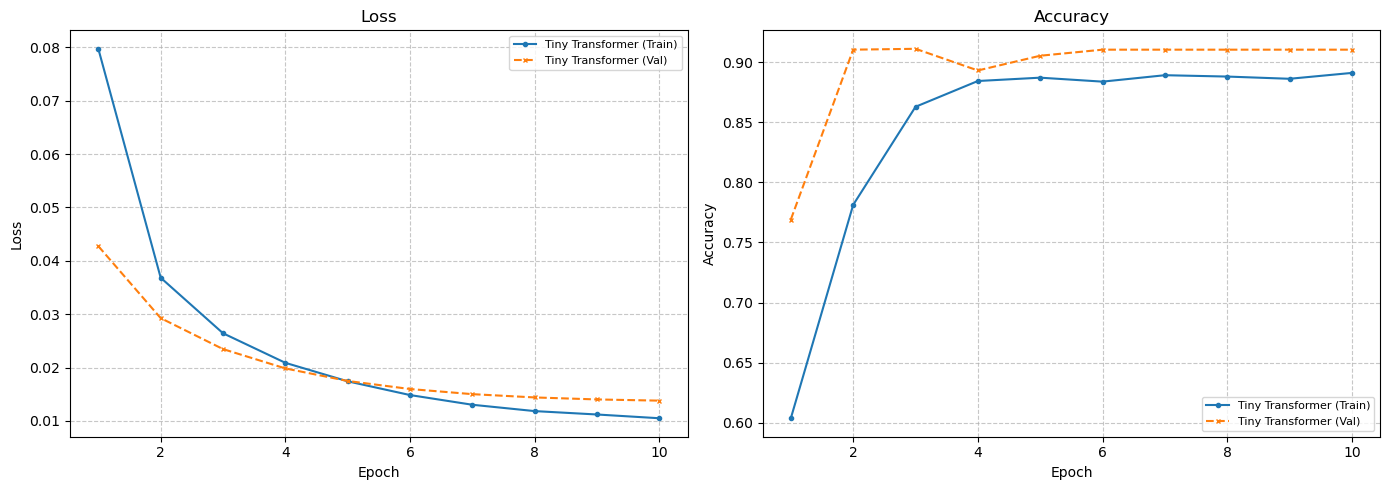

In [114]:
torch.manual_seed(0)
tiny_tf = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    num_classes=len(LABELS),
).to(device)

criterion = nn.BCEWithLogitsLoss(task1_label_weights)
optimizer = optim.Adam(tiny_tf.parameters(), lr=1e-3)

print(f'Parameters: {sum(p.numel() for p in tiny_tf.parameters()):,}')

all_results = {}
all_results['Tiny Transformer'] = run_experiment(
    tiny_tf, optimizer, criterion, train_loader, val_loader,
    epochs=10, name='Tiny TF'
)

plot_experiments(all_results)